# YOLOv11 训练 Notebook

# 1. 环境准备 & 导入包
按照 README.md 文档中，将环境准备好之后，在训练代码中导入包

In [7]:
from ultralytics import YOLO                    # YOLOv11 模型接口
import yaml                                     # 用于读取 YAML 配置文件
from IPython.display import Image, display      # 用于显示图片
import os                                       # 文件与路径操作

print('环境准备完成：依赖包已导入')

环境准备完成：依赖包已导入


# 2. 加载模型 & 权重
加载 YOLOv11 模型配置，并（可选）加载预训练权重

In [8]:
model_cfg = 'ultralytics/cfg/models/yolo11s.yaml'  # 模型配置文件路径
pretrained_weights = 'datasets/weeds/weeds.pt'     # 预训练权重路径（可选）

# 加载模型配置
model = YOLO(model_cfg)
print(f'已加载模型配置：{model_cfg}')

# 如果预训练权重存在，则加载它
if os.path.exists(pretrained_weights):
    model.load(pretrained_weights)
    print(f'已加载预训练权重：{pretrained_weights}')
else:
    print(f'未找到预训练权重，跳过加载：{pretrained_weights}')

已加载模型配置：ultralytics/cfg/models/yolo11s.yaml
Transferred 493/499 items from pretrained weights
已加载预训练权重：datasets/weeds/weeds.pt


# 3. 检查数据集配置
打开并打印 `datasets/weeds.yaml`，确认 paths 正确

In [9]:
data_cfg_path = 'datasets/weeds.yaml'  # 数据集配置文件
# 读取 YAML
with open(data_cfg_path, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)
print(f'已读取数据集配置：{data_cfg_path}')
print('配置内容：')
print(data_cfg)

# 验证关键字段存在
assert 'train' in data_cfg and 'val' in data_cfg, '数据集配置缺少 train 或 val 路径'
print('数据集配置检查通过')

已读取数据集配置：datasets/weeds.yaml
配置内容：
{'path': 'datasets/weeds/images/', 'train': 'train', 'val': 'train', 'test': 'train', 'nc': 3, 'names': {0: 'baicao', 1: 'rand', 2: 'weed'}}
数据集配置检查通过


# 4. 配置训练参数
- 设置训练参数：图像尺寸、批量大小、Epoch 数量等

In [10]:
train_params = {
    'data': data_cfg_path,   # 数据配置路径
    'imgsz': 640,            # 输入图像尺寸
    'epochs': 2,            # 训练轮数
    'batch': 8,              # 批大小
    'workers': 4,            # 数据加载进程数
    'device': 'cpu',             # GPU id 或 'cpu'
    'project': 'runs/train', # 保存结果的项目目录
    'name': 'exp',           # 结果子目录名称
}
print('训练参数：')
print(train_params)

训练参数：
{'data': 'datasets/weeds.yaml', 'imgsz': 640, 'epochs': 2, 'batch': 8, 'workers': 4, 'device': 'cpu', 'project': 'runs/train', 'name': 'exp'}


# 5. 启动训练
- 训练过程需等待，图片越多，epochs 轮次越大，等待时间越长。

In [11]:
# 启动训练
print('开始训练...')
model.train(**train_params)
print('训练完成！')

开始训练...
Ultralytics 8.3.136  Python-3.12.9 torch-2.6.0+cpu CPU (13th Gen Intel Core(TM) i9-13900H)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/weeds.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=ultralytics/cfg/models/yolo11s.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

train: Scanning C:\Users\85827\Desktop\Deep-learning-main\datasets\weeds\labels\train.cache... 80 i

albumentations: ImageCompression.__init__() got an unexpected keyword argument 'quality_range'
val: Fast image access  (ping: 0.20.0 ms, read: 272.942.2 MB/s, size: 64.9 KB)



val: Scanning C:\Users\85827\Desktop\Deep-learning-main\datasets\weeds\labels\train.cache... 80 ima

Plotting labels to runs\train\exp2\labels.jpg... 


...

        2/2         0G      1.639      2.069      2.213         40        640: 100%|██████████| 10/
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|████

                   all         80        171      0.486      0.729      0.554      0.335



2 epochs completed in 0.079 hours.
Optimizer stripped from runs\train\exp2\weights\last.pt, 19.2MB
Optimizer stripped from runs\train\exp2\weights\best.pt, 19.2MB

Validating runs\train\exp2\weights\best.pt...
Ultralytics 8.3.136  Python-3.12.9 torch-2.6.0+cpu CPU (13th Gen Intel Core(TM) i9-13900H)
YOLO11s summary (fused): 100 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|████


                   all         80        171      0.486      0.729      0.555      0.335
                baicao         65        142      0.786      0.754        0.8      0.539
                  rand         18         18      0.344      0.889      0.539      0.315
                  weed         11         11      0.329      0.545      0.326      0.152
Speed: 4.3ms preprocess, 378.9ms inference, 0.0ms loss, 15.5ms postprocess per image
Results saved to runs\train\exp2
训练完成！


# 6. 可视化训练结果
- 训练结束后，在 `runs/train/exp` 目录下生成 `results.png`
- 首次训练保存路径：`runs/train/exp`
- 请查看`5. 启动训练`输出的实际路劲，如：Results saved to runs\train\exp
- 使用 matplotlib 显示训练曲线

已找到文件，正在显示：runs/train/exp2/results.png


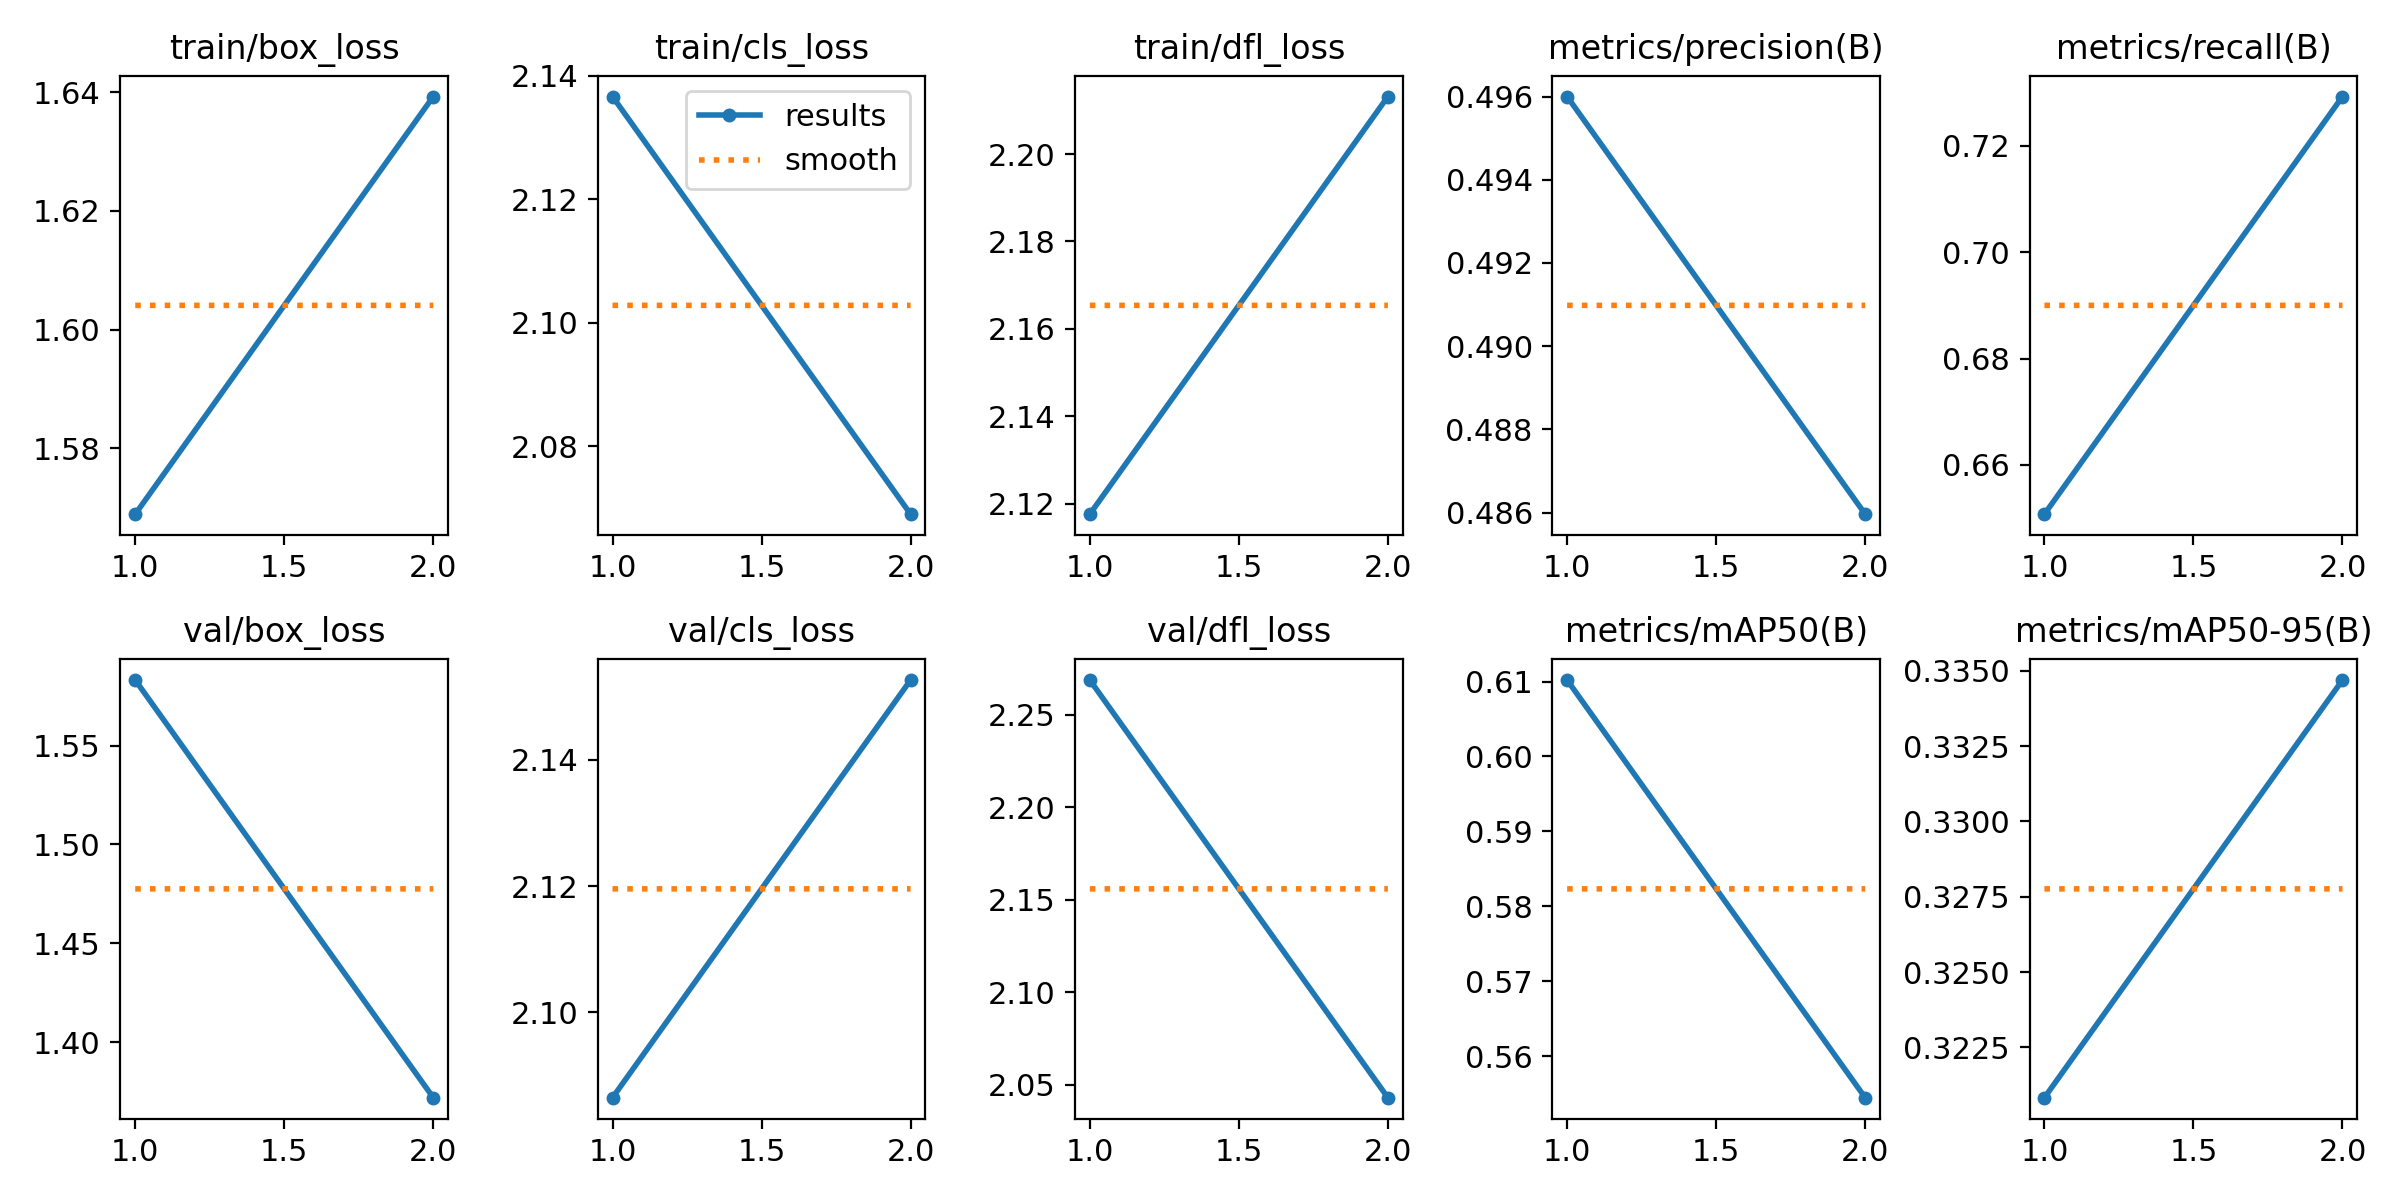

In [13]:
# 你的训练曲线文件路径
img_path = 'runs/train/exp2/results.png'

if os.path.exists(img_path):
    print(f'已找到文件，正在显示：{img_path}')
    display(Image(img_path))
else:
    print(f'提示：未找到文件，请检查路径是否正确：{img_path}')